In [33]:
!pip install scipy PyWavelets -q

import requests, io
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import scipy.io as iomat
import helpers
from TIMBRE import TIMBRE
import pywt

# --- Load data ---
url = "https://api.figshare.com/v2/articles/24757638"
files = requests.get(url).json()['files']
f = next(x for x in files if x['name'] == 'data04.mat')
data = iomat.loadmat(io.BytesIO(requests.get(f['download_url']).content))

# --- Preprocess ---
LFPs = helpers.filter_data(data['lfps'], 2, fs=25, use_hilbert=True)
test_inds, train_inds = helpers.test_train(data['lapID'], which_phase=2, n_folds=5, which_fold=0)
wLFPs, _, _ = helpers.whiten(LFPs, train_inds)
print(f"LFPs shape: {LFPs.shape}, electrodes: {LFPs.shape[1]}")



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
LFPs shape: (91710, 192), electrodes: 192


In [42]:
m0,  _, _ = TIMBRE(LFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=0)
m3,  _, _ = TIMBRE(LFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=3)
m6, _, _ = TIMBRE(LFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)

In [43]:
def get_complex_weights(model, n_nodes):
    Wr, Wi = model.layers[0].get_weights()     
    return Wr + 1j * Wi

W0 = get_complex_weights(m0, 0)   # (n_elec, 3) — column i = filter for arm i
W3 = get_complex_weights(m3, 3)   # (n_elec, 3)
W6 = get_complex_weights(m6, 6)   # (n_elec, 6)

n_elec = W0.shape[0]
print(f"W0: {W0.shape}, W3: {W3.shape}, W6: {W6.shape}")


W0: (192, 3), W3: (192, 3), W6: (192, 6)


In [44]:
n_bins = 20
pos_binned         = helpers.group_by_pos(data['lapID'][:, 4], n_bins, train_inds)
pos_binned_clipped = np.clip(pos_binned, 0, n_bins - 1)           # keep bins in 0-19
arm_and_pos_binned = data['lapID'][:, 1] * n_bins + pos_binned_clipped
  # bins 0-19 = arm1, 20-39 = arm2, 40-59 = arm3

def node_arm_map(model, top_k=1):
    p         = helpers.layer_output(wLFPs[test_inds], model, 2)
    avg       = helpers.accumarray(arm_and_pos_binned[test_inds], p, size=(3 * n_bins,))  # force (60, n_nodes)
    arm_means = avg.reshape(3, n_bins, p.shape[1]).mean(axis=1)   # (3, n_nodes)
    return [list(np.argsort(arm_means[arm])[-top_k:][::-1]) for arm in range(3)]

arm_nodes_m3 = node_arm_map(m3, top_k=1)
arm_nodes_m6 = node_arm_map(m6, top_k=2)
print("m3:", arm_nodes_m3)
print("m6:", arm_nodes_m6)

221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 232us/step
m3: [[np.int64(2)], [np.int64(2)], [np.int64(0)]]
m6: [[np.int64(5), np.int64(4)], [np.int64(3), np.int64(4)], [np.int64(4), np.int64(1)]]


In [45]:
def plot_weight_scatter(W_0node, W_3node, W_6node, arm_idx, channel_labels=None):
    """
    W_1node: (n_channels,) complex array - weights for this arm, 0-node TIMBRE
    W_3node: (n_channels,) complex array - weights for this arm, 3-node TIMBRE  
    W_6node: (n_channels, 2) complex array - weights for this arm, 6-node TIMBRE
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    n = len(W_0node)
    
    for ax, (W, label) in zip(axes, [
        (W_0node[:, None], '0 node'),
        (W_3node[:, None], '3 nodes'),
        (W_6node,          '6 nodes'),
    ]):
        ax.scatter(W[:, 0].real, W[:, 0].imag, alpha=0.6, s=20)
        
        if W.shape[1] == 2:  # 6-node case: draw connecting lines
            for ch in range(n):
                ax.plot(
                    [W[ch, 0].real, W[ch, 1].real],
                    [W[ch, 0].imag, W[ch, 1].imag],
                    'k-', alpha=0.2, linewidth=0.5
                )
            ax.scatter(W[:, 1].real, W[:, 1].imag, 
                      alpha=0.6, s=20, marker='^')
        
        ax.axhline(0, color='gray', linewidth=0.5)
        ax.axvline(0, color='gray', linewidth=0.5)
        ax.set_xlabel('Re(weight)')
        ax.set_ylabel('Im(weight)')
        ax.set_title(f'Arm {arm_idx+1} — {label}')
        ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

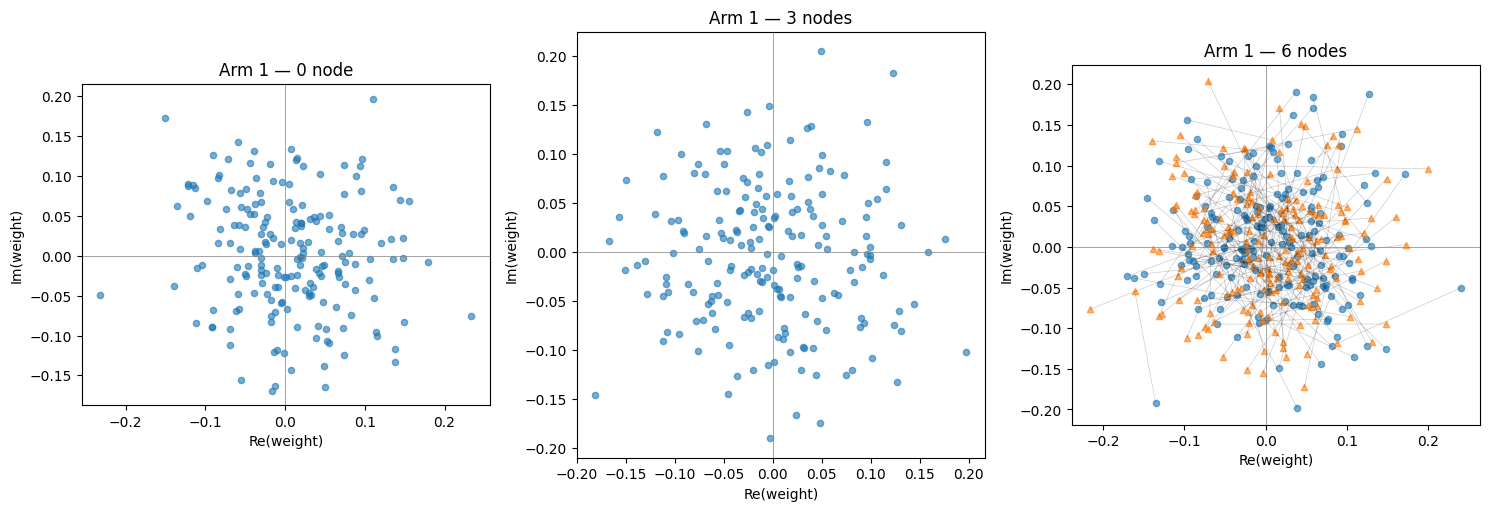

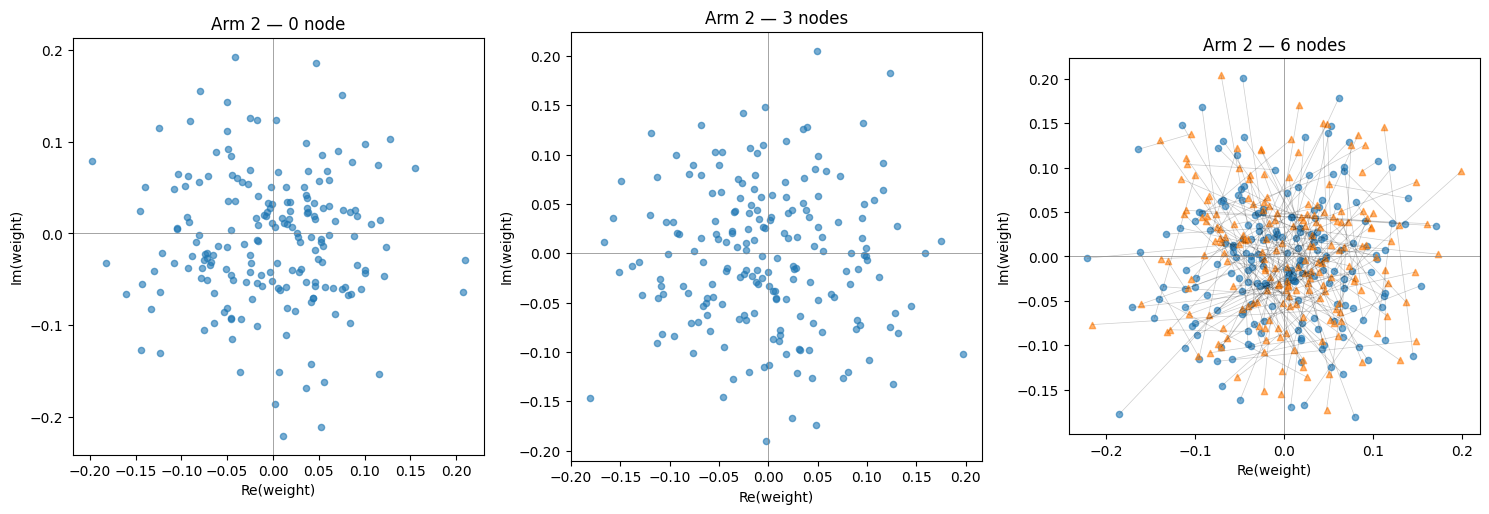

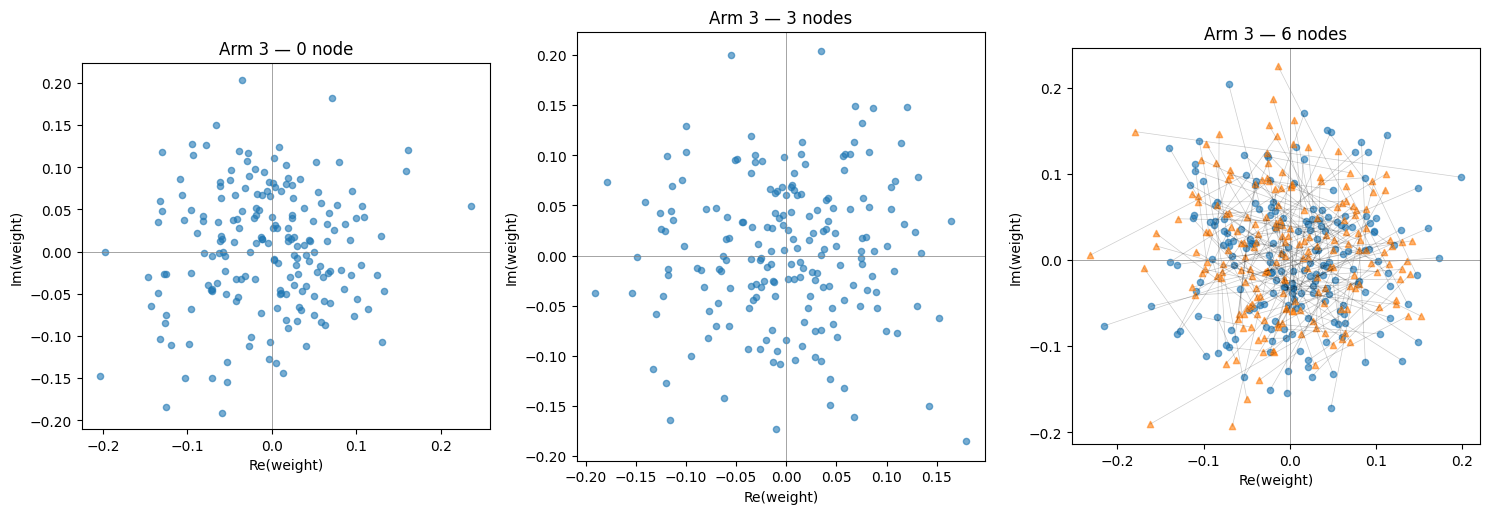

In [46]:
for arm_idx in range(3):
    # m0: column arm_idx is directly the filter for that arm
    W_1node = W0[:, arm_idx]

    # m3: pick the node that accumarray assigned to this arm
    node3   = arm_nodes_m3[arm_idx][0]
    W_3node = W3[:, node3]

    # m6: pick the two nodes assigned to this arm, stack to (n_elec, 2)
    n0, n1  = arm_nodes_m6[arm_idx]
    W_6node = np.stack([W6[:, n0], W6[:, n1]], axis=1)

    plot_weight_scatter(W_1node, W_3node, W_6node, arm_idx)
    plt.show()
